# Gaussian Beam Propagation

Create a scalar Gaussian beam at its waist and propagate it with the angular spectrum method. All spatial values in this example use millimeters.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt

import optiland.backend as be
from optiland.physical_optics import gaussian_field

In [2]:
wavelength = 0.0006328
field = gaussian_field(
    shape=(256, 256),
    dx=0.01,
    wavelength=wavelength,
    waist_radius=0.25,
)
propagated = field.propagate(200.0)

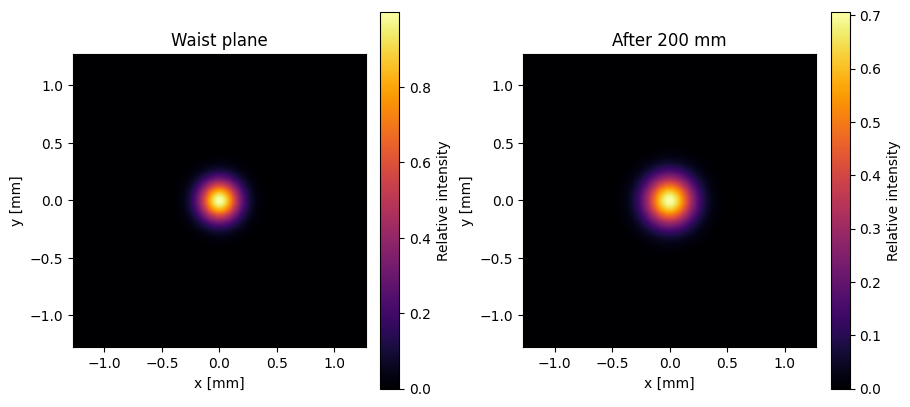

In [3]:
x, y = propagated.coordinates()
extent = [
    float(be.to_numpy(x[0])),
    float(be.to_numpy(x[-1])),
    float(be.to_numpy(y[0])),
    float(be.to_numpy(y[-1])),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for axis, beam, title in zip(
    axes,
    (field, propagated),
    ("Waist plane", "After 200 mm"),
    strict=True,
):
    image = axis.imshow(
        be.to_numpy(beam.intensity),
        extent=extent,
        origin="lower",
        cmap="inferno",
    )
    axis.set(title=title, xlabel="x [mm]", ylabel="y [mm]")
    fig.colorbar(image, ax=axis, label="Relative intensity")

plt.show()